In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/rashida048/Datasets/master/movie_dataset.csv")
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

   index     budget                                    genres  \
0      0  237000000  Action Adventure Fantasy Science Fiction   
1      1  300000000                  Adventure Fantasy Action   
2      2  245000000                    Action Adventure Crime   
3      3  250000000               Action Crime Drama Thriller   
4      4  260000000          Action Adventure Science Fiction   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  culture clash future space war space colony so...                en   
1  ocean drug abuse exotic island east india trad...                en   
2         spy based on novel sec

In [4]:
drop_cols = [
    "overview", "genres", "production_companies", "production_countries",
    "spoken_languages", "cast", "crew", "original_title", "title",
    "director", "release_date", "homepage", "keywords", "tagline", "index", "id"
]
df = df.drop(columns=drop_cols, errors="ignore")
print(df.columns)

Index(['budget', 'original_language', 'popularity', 'revenue', 'runtime',
       'status', 'vote_average', 'vote_count'],
      dtype='object')


In [5]:
df["runtime"] = df["runtime"].fillna(df["runtime"].mean())
df = pd.get_dummies(df, columns=["status", "original_language"], dtype=int)
print(df)

         budget  popularity     revenue  runtime  vote_average  vote_count  \
0     237000000  150.437577  2787965087    162.0           7.2       11800   
1     300000000  139.082615   961000000    169.0           6.9        4500   
2     245000000  107.376788   880674609    148.0           6.3        4466   
3     250000000  112.312950  1084939099    165.0           7.6        9106   
4     260000000   43.926995   284139100    132.0           6.1        2124   
...         ...         ...         ...      ...           ...         ...   
4798     220000   14.269792     2040920     81.0           6.6         238   
4799       9000    0.642552           0     85.0           5.9           5   
4800          0    1.444476           0    120.0           7.0           6   
4801          0    0.857008           0     98.0           5.7           7   
4802          0    1.929883           0     90.0           6.3          16   

      status_Post Production  status_Released  status_Rumored  

In [6]:
X = df.drop("revenue", axis=1)
Y = df["revenue"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
pred_lr = lr.predict(X_test)
print("Linear R2:", r2_score(Y_test, pred_lr))
print("Linear RMSE:", np.sqrt(mean_squared_error(Y_test, pred_lr)))

Linear R2: 0.7484547887562754
Linear RMSE: 80942958.52717747


In [8]:
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, Y_train)
pred_rf = rf.predict(X_test)
print("RandomForest R2:", r2_score(Y_test, pred_rf))
print("RandomForest RMSE:", np.sqrt(mean_squared_error(Y_test, pred_rf)))

RandomForest R2: 0.7351152232462547
RandomForest RMSE: 83061457.39713588


In [9]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, Y_train)
pred_knn = knn.predict(X_test)
print("KNN R2:", r2_score(Y_test, pred_knn))
print("KNN RMSE:", np.sqrt(mean_squared_error(Y_test, pred_knn)))

KNN R2: 0.7114066051643493
KNN RMSE: 86699030.42161568


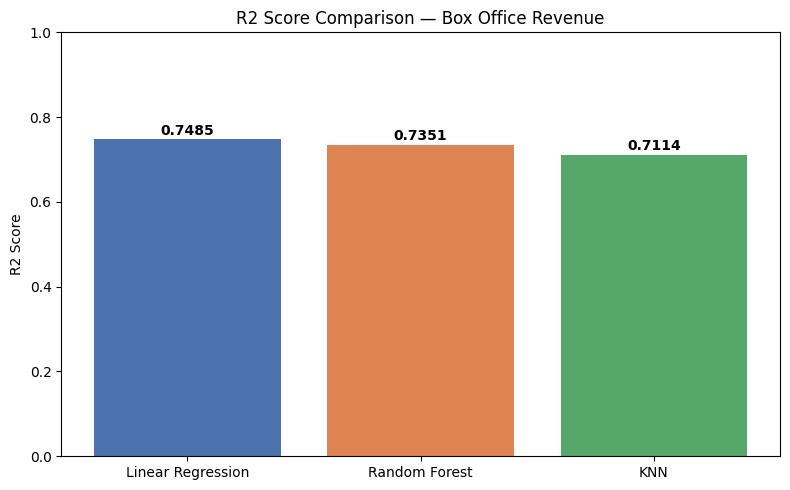

In [10]:
models = ["Linear Regression", "Random Forest", "KNN"]
r2_scores = [
    r2_score(Y_test, pred_lr),
    r2_score(Y_test, pred_rf),
    r2_score(Y_test, pred_knn)
]

plt.figure(figsize=(8, 5))
plt.bar(models, r2_scores, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("R2 Score Comparison — Box Office Revenue")
plt.ylabel("R2 Score")
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, str(round(v, 4)), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()